In [1]:
from simbanator.io.simba import Simulation
from simbanator.analysis.particles import extract_particles

# Load your simulation (use the name you configured)
sim = Simulation("test_sim")  # Replace XX with your snapshot number

# Load the Caesar catalog for this snapshot
obj = sim.load_catalog(44)
snap_path = sim.get_snapshot_file(44)

yt : [INFO     ] 2026-03-08 14:26:13,330 Opening /media/lorenzong/Data1/simba_hig_res/m25n512_044.hdf5
yt : [INFO     ] 2026-03-08 14:26:13,343 Found 171287 halos
yt : [INFO     ] 2026-03-08 14:26:13,345 Found 1773 galaxies


In [2]:
print(obj)
print(snap_path)

/media/lorenzong/Data1/simba_hig_res/snap_m25n512_044.hdf5


In [3]:
# Find the central galaxy of the most massive halo
halos = obj.halos
most_massive_halo = max(halos, key=lambda h: h.masses['total'])
central_gal_id = [i.GroupID for i in obj.galaxies if i.central==1 and i.GroupID in most_massive_halo.galaxy_index_list][0]
central_gal = [g for g in obj.galaxies if g.GroupID == central_gal_id][0]
print(f"Central galaxy GroupID: {central_gal.GroupID}")

Central galaxy GroupID: 1


In [4]:
obj.galaxies[central_gal_id]

In [7]:
# Filter star/gas particles belonging to the central galaxy
filtered = extract_particles(obj, snap_path, snap=44, galaxy_id=central_gal_id)

Reading snapshot: /media/lorenzong/Data1/simba_hig_res/snap_m25n512_044.hdf5
PartType0 particles: 5005
PartType4 particles: 5582
Finished extraction → filtered_snap44.h5


yt : [INFO     ] 2026-03-08 12:54:10,153 ComovingIntegrationOn does not exist, falling back to OmegaLambda
yt : [INFO     ] 2026-03-08 12:54:10,169 Calculating time from 1.736e-01 to be 3.986e+16 seconds
yt : [INFO     ] 2026-03-08 12:54:10,170 Assuming length units are in kpc/h (comoving)
yt : [INFO     ] 2026-03-08 12:54:10,210 Parameters: current_time              = 3.9858341761438936e+16 s
yt : [INFO     ] 2026-03-08 12:54:10,211 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-03-08 12:54:10,211 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 12:54:10,211 Parameters: domain_right_edge         = [25000. 25000. 25000.]
yt : [INFO     ] 2026-03-08 12:54:10,212 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-03-08 12:54:10,212 Parameters: current_redshift          = 4.761397524829645
yt : [INFO     ] 2026-03-08 12:54:10,212 Parameters: omega_lambda              = 0.7
yt : [INFO     ] 2026-03-08 12:54:10,212 Paramet

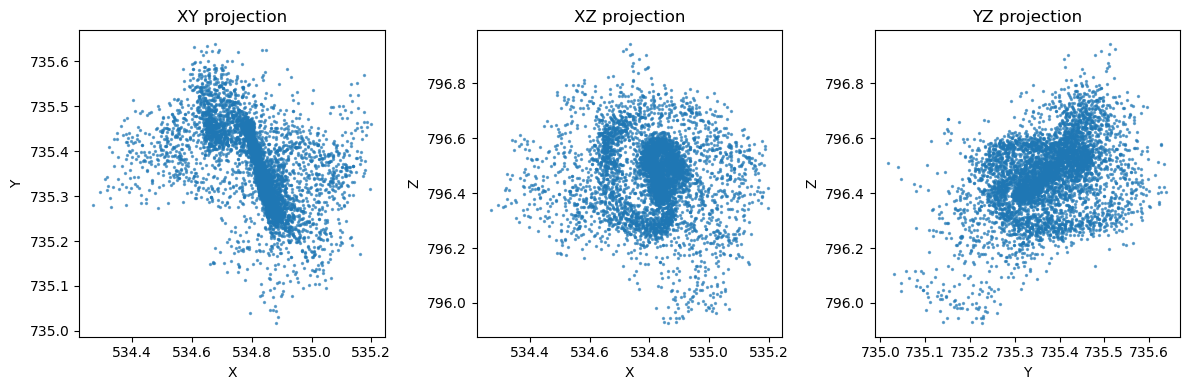

In [9]:
from simbanator.visualization.rendering import ParticleProjectionRender
proj = ParticleProjectionRender(snap_path, sim.get_caesar_file(snap=44), central_gal_id, particle_type='PartType0')
proj.plot()

yt : [INFO     ] 2026-03-08 13:37:36,395 ComovingIntegrationOn does not exist, falling back to OmegaLambda
yt : [INFO     ] 2026-03-08 13:37:36,402 Calculating time from 1.736e-01 to be 3.986e+16 seconds
yt : [INFO     ] 2026-03-08 13:37:36,403 Assuming length units are in kpc/h (comoving)
yt : [INFO     ] 2026-03-08 13:37:36,448 Parameters: current_time              = 3.9858341761438936e+16 s
yt : [INFO     ] 2026-03-08 13:37:36,448 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-03-08 13:37:36,449 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 13:37:36,449 Parameters: domain_right_edge         = [25000. 25000. 25000.]
yt : [INFO     ] 2026-03-08 13:37:36,450 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-03-08 13:37:36,450 Parameters: current_redshift          = 4.761397524829645
yt : [INFO     ] 2026-03-08 13:37:36,450 Parameters: omega_lambda              = 0.7
yt : [INFO     ] 2026-03-08 13:37:36,451 Paramet

Positions in code units: [[12069.47949219 16593.18554688 17974.05859375]
 [12070.33300781 16593.1484375  17974.38085938]
 [12070.96972656 16593.34179688 17974.08984375]
 ...
 [12071.55566406 16599.47265625 17979.046875  ]
 [12071.61914062 16599.52148438 17978.88671875]
 [12070.75390625 16596.00585938 17979.11914062]] code_length
Positions in kpc: [[3080.71686962 4235.3861795  4587.85199156]
 [3080.93472823 4235.37670739 4587.93424939]
 [3081.09724975 4235.42606209 4587.85996808]
 ...
 [3081.24680944 4236.99095491 4589.125243  ]
 [3081.26301173 4237.00341822 4589.08436336]
 [3081.04216193 4236.10606012 4589.1436887 ]] kpc


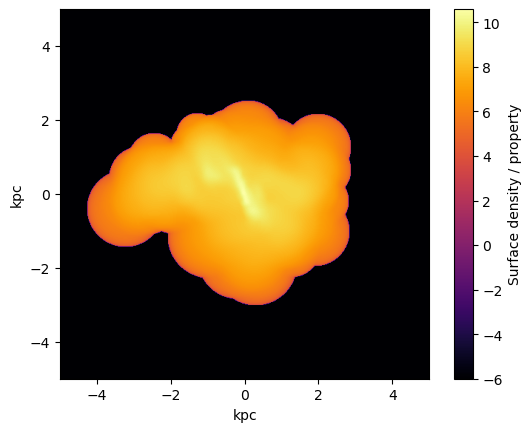

In [4]:
from simbanator.visualization.rendering import ParticleSelector, SPHRenderer, SimulationData
import matplotlib.pyplot as plt
import numpy as np

simd = SimulationData(
    sim.get_snapshot_file(44),
    sim.get_caesar_file(snap=44)
)

selector = ParticleSelector(simd)

idx = selector.galaxy(1,"PartType0")

pos, mass = simd.get_particles("PartType0","Masses",idx,"Msun")

renderer = SPHRenderer(simd)

center = simd.obj.galaxies[1].minpotpos.in_units("kpc").value

img = renderer.render(pos, mass, center, extent=5)
renderer.show(img)



In [5]:
import sphviewer as sph
import numpy as np
import matplotlib.pyplot as plt

class SPHRenderer:
    """
    SPHViewer renderer for galaxy-centered particle distributions.
    """

    def __init__(self, sim, use_hsml=True):
        """
        Parameters
        ----------
        sim : SimulationData
            Your simulation interface (snapshot + Caesar catalog)
        use_hsml : bool
            Whether to use smoothing lengths from the simulation
        """
        self.sim = sim
        self.extent = None
        self.use_hsml = use_hsml

    def render(self, pos, mass, center=None, hsml=None,
               extent=5, xsize=500, ysize=500, theta=0, phi=0):
        """
        Render SPH particles projected onto a plane.

        Parameters
        ----------
        pos : ndarray
            Nx3 particle positions (kpc)
        mass : ndarray
            N particle masses
        center : ndarray
            3-element array for galaxy center (kpc)
        hsml : ndarray
            Optional smoothing lengths (kpc)
        extent : float
            Half-width of box to render (kpc)
        xsize, ysize : int
            Output image pixels
        theta, phi : float
            Rotation angles in degrees
        """

        # Default center is galaxy center at 0
        if center is None:
            center = np.array([0.,0.,0.])

        # Shift to galaxy-centered coordinates
        pos_shifted = pos - center

        # Rotate coordinates
        theta_rad = np.radians(theta)
        phi_rad   = np.radians(phi)
        Rz = np.array([
            [np.cos(theta_rad), -np.sin(theta_rad), 0],
            [np.sin(theta_rad),  np.cos(theta_rad), 0],
            [0,0,1]
        ])
        Ry = np.array([
            [np.cos(phi_rad),0,np.sin(phi_rad)],
            [0,1,0],
            [-np.sin(phi_rad),0,np.cos(phi_rad)]
        ])
        pos_rot = pos_shifted @ (Rz @ Ry).T

        # Use SPH smoothing lengths if provided
        if self.use_hsml and hsml is not None:
            particles = sph.Particles(pos_rot, mass, hsml)
        else:
            particles = sph.Particles(pos_rot, mass)

        # Define camera at origin (galaxy-centered)
        camera = sph.Camera(
            x=0, y=0, z=0,
            r="infinity",
            t=0, p=0, roll=0,
            extent=[-extent, extent, -extent, extent],
            xsize=xsize,
            ysize=ysize
        )

        # Create scene and render
        scene = sph.Scene(particles, Camera=camera)
        render = sph.Render(scene)

        self.extent = render.get_extent()
        return render.get_image()

    def show(self, img, log=True, cmap="inferno"):
        """
        Display the rendered image.
        """
        plt.figure(figsize=(8,8))
        if log:
            img = np.log10(img + 1e-6)
        plt.imshow(img, origin="lower", extent=self.extent, cmap=cmap)
        plt.xlabel("kpc")
        plt.ylabel("kpc")
        plt.colorbar(label="Projected density (arbitrary units)")
        plt.show()

yt : [INFO     ] 2026-03-08 13:58:49,519 ComovingIntegrationOn does not exist, falling back to OmegaLambda
yt : [INFO     ] 2026-03-08 13:58:49,524 Calculating time from 1.736e-01 to be 3.986e+16 seconds
yt : [INFO     ] 2026-03-08 13:58:49,524 Assuming length units are in kpc/h (comoving)
yt : [INFO     ] 2026-03-08 13:58:49,558 Parameters: current_time              = 3.9858341761438936e+16 s
yt : [INFO     ] 2026-03-08 13:58:49,558 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-03-08 13:58:49,558 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 13:58:49,559 Parameters: domain_right_edge         = [25000. 25000. 25000.]
yt : [INFO     ] 2026-03-08 13:58:49,559 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-03-08 13:58:49,559 Parameters: current_redshift          = 4.761397524829645
yt : [INFO     ] 2026-03-08 13:58:49,560 Parameters: omega_lambda              = 0.7
yt : [INFO     ] 2026-03-08 13:58:49,560 Paramet

Positions in code units: [[12069.47949219 16593.18554688 17974.05859375]
 [12070.33300781 16593.1484375  17974.38085938]
 [12070.96972656 16593.34179688 17974.08984375]
 ...
 [12071.55566406 16599.47265625 17979.046875  ]
 [12071.61914062 16599.52148438 17978.88671875]
 [12070.75390625 16596.00585938 17979.11914062]] code_length
Positions in kpc: [[3080.71686962 4235.3861795  4587.85199156]
 [3080.93472823 4235.37670739 4587.93424939]
 [3081.09724975 4235.42606209 4587.85996808]
 ...
 [3081.24680944 4236.99095491 4589.125243  ]
 [3081.26301173 4237.00341822 4589.08436336]
 [3081.04216193 4236.10606012 4589.1436887 ]] kpc


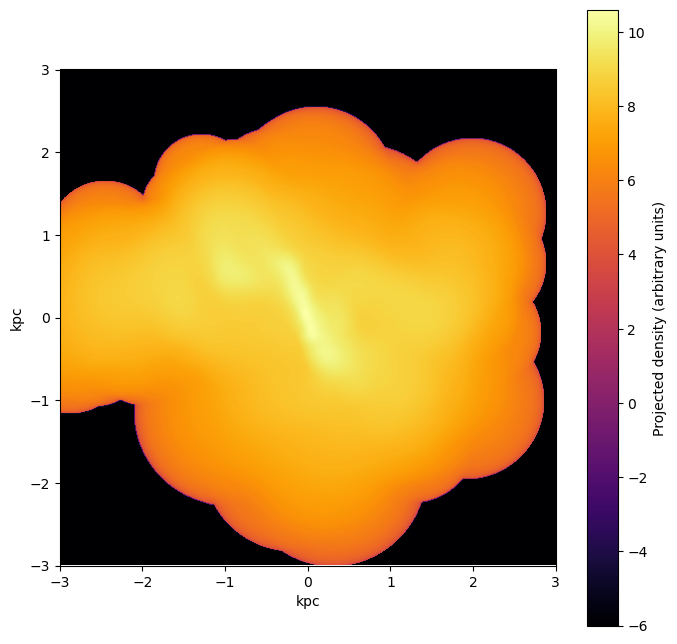

In [23]:

simd = SimulationData(
    sim.get_snapshot_file(44),
    sim.get_caesar_file(snap=44),
    
)

selector = ParticleSelector(simd)

idx = selector.galaxy(1,"PartType0")

pos, mass = simd.get_particles("PartType0","Masses",idx,"Msun")

renderer = SPHRenderer(simd)

center = simd.obj.galaxies[1].minpotpos.in_units("kpc").value

img = renderer.render(pos, mass, center, extent=3)
renderer.show(img)



In [9]:
# Show min/max for each column in pos (assumed Nx3)
import numpy as np
for i, axis in enumerate(['X', 'Y', 'Z']):
    print(f"{axis}: min={np.min(pos[:,i]):.3f} kpc, max={np.max(pos[:,i]):.3f} kpc", np.max(pos[:,i])- np.min(pos[:,i]))

X: min=3078.136 kpc, max=3083.487 kpc 5.351744031425369
Y: min=4234.731 kpc, max=4238.303 kpc 3.571983789955084
Z: min=4585.657 kpc, max=4591.498 kpc 5.84130273089977


In [17]:
r = [i.radii['stellar_r80'] for i in obj.galaxies if i.GroupID == central_gal_id]
print(f"Stellar radius (R80): {r[0]:.3f}")
print(r[0].value*obj.simulation.scale_factor)

Stellar radius (R80): 5.945 kpccm
1.031843560454017


In [13]:
obj.simulation.scale_factor

0.17356899878724621

AttributeError: 'CAESAR' object has no attribute 'redshifts'

yt : [INFO     ] 2026-03-08 14:12:49,066 ComovingIntegrationOn does not exist, falling back to OmegaLambda
yt : [INFO     ] 2026-03-08 14:12:49,073 Calculating time from 1.736e-01 to be 3.986e+16 seconds
yt : [INFO     ] 2026-03-08 14:12:49,073 Assuming length units are in kpc/h (comoving)
yt : [INFO     ] 2026-03-08 14:12:49,114 Parameters: current_time              = 3.9858341761438936e+16 s
yt : [INFO     ] 2026-03-08 14:12:49,114 Parameters: domain_dimensions         = [1 1 1]
yt : [INFO     ] 2026-03-08 14:12:49,115 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2026-03-08 14:12:49,115 Parameters: domain_right_edge         = [25000. 25000. 25000.]
yt : [INFO     ] 2026-03-08 14:12:49,116 Parameters: cosmological_simulation   = True
yt : [INFO     ] 2026-03-08 14:12:49,116 Parameters: current_redshift          = 4.761397524829645
yt : [INFO     ] 2026-03-08 14:12:49,116 Parameters: omega_lambda              = 0.7
yt : [INFO     ] 2026-03-08 14:12:49,117 Paramet

Positions in code units: [[11571.96679688 17156.52539062 18327.42578125]
 [11570.68554688 17157.38671875 18330.84765625]
 [11571.6015625  17155.24609375 18326.29296875]
 ...
 [11572.0703125  17154.84960938 18333.5234375 ]
 [11571.31738281 17154.83007812 18334.234375  ]
 [11571.82421875 17154.88867188 18333.69726562]] code_length
Positions in kpc: [[2953.72748667 4379.17784517 4678.04844588]
 [2953.40044949 4379.39769791 4678.92187444]
 [2953.63426113 4378.85130653 4677.75929716]
 ...
 [2953.75390888 4378.75010448 4679.60486366]
 [2953.56172468 4378.74511916 4679.78632941]
 [2953.69109381 4378.76007512 4679.64923303]] kpc
Positions in code units: [[11571.02246094 17149.4453125  18326.43359375]
 [11571.70410156 17154.94140625 18323.375     ]
 [11571.28417969 17154.28710938 18323.56835938]
 ...
 [11570.94140625 17158.50390625 18323.55078125]
 [11571.12597656 17157.91015625 18324.9921875 ]
 [11572.57519531 17157.265625   18328.50976562]] code_length
Positions in kpc: [[2953.48644631 4377.3

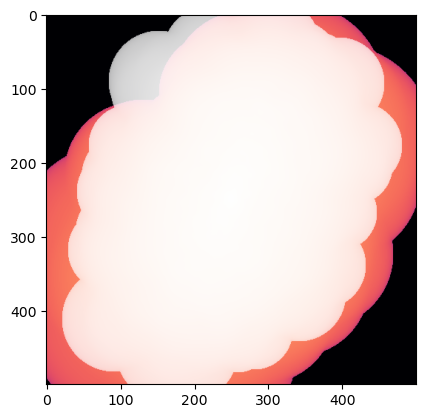

In [4]:
from simbanator.visualization.rendering import SimulationData, MasterRenderer
# 1. Setup
sim = SimulationData(
    sim.get_snapshot_file(44),
    sim.get_caesar_file(snap=44)
)
viz = MasterRenderer(sim)

# 2. Generate a Face-on RGB Image
rgb_img = viz.render_galaxy_rgb(gal_id=0, view='faceon', extent=3)
import matplotlib.pyplot as plt
plt.imshow(rgb_img)
plt.show()


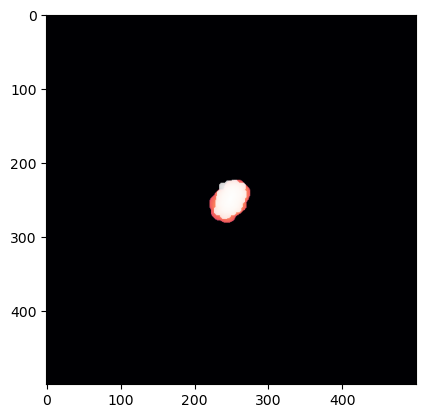

Positions in code units: [[11571.02246094 17149.4453125  18326.43359375]
 [11571.70410156 17154.94140625 18323.375     ]
 [11571.28417969 17154.28710938 18323.56835938]
 ...
 [11570.94140625 17158.50390625 18323.55078125]
 [11571.12597656 17157.91015625 18324.9921875 ]
 [11572.57519531 17157.265625   18328.50976562]] code_length
Positions in kpc: [[2953.48644631 4377.37066566 4677.79519148]
 [2953.66043407 4378.7735355  4677.01448993]
 [2953.55324963 4378.60652718 4677.06384463]
 ...
 [2953.46575722 4379.68285837 4677.05935784]
 [2953.51286852 4379.53130456 4677.42727466]
 [2953.88277947 4379.36678891 4678.3251313 ]] kpc
Positions in code units: [[11571.02246094 17149.4453125  18326.43359375]
 [11571.70410156 17154.94140625 18323.375     ]
 [11571.28417969 17154.28710938 18323.56835938]
 ...
 [11570.94140625 17158.50390625 18323.55078125]
 [11571.12597656 17157.91015625 18324.9921875 ]
 [11572.57519531 17157.265625   18328.50976562]] code_length
Positions in kpc: [[2953.48644631 4377.3

AttributeError: 'QuickView' object has no attribute 'params'

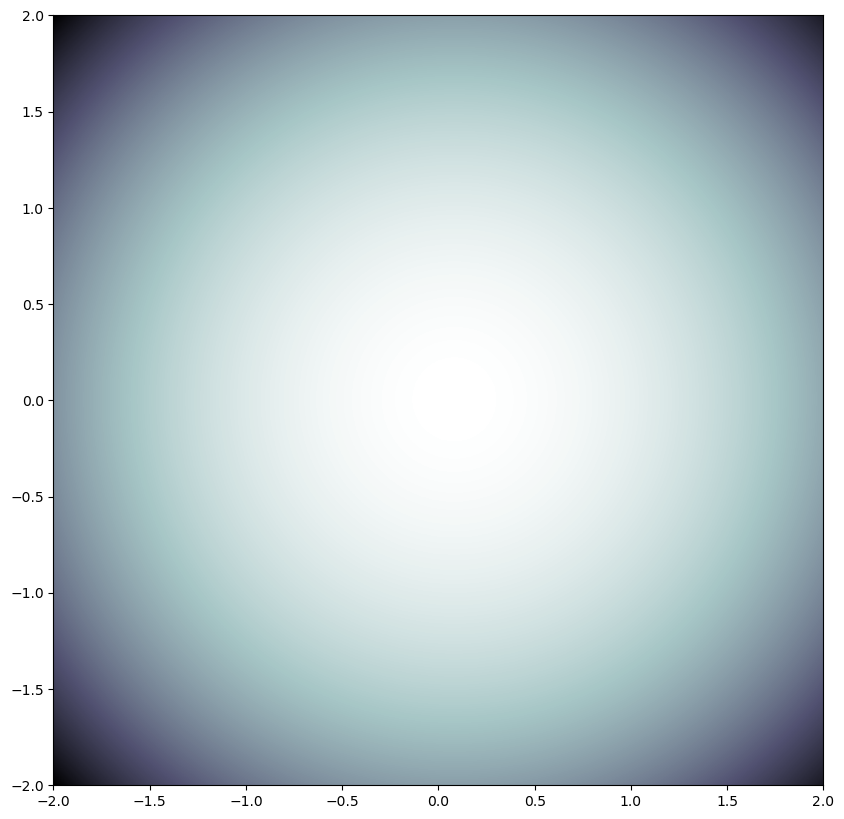

In [6]:

plt.imshow(rgb_img)
plt.show()


In [ ]:
# Render an RGB image of the central galaxy using the RenderRGB module
from simbanator.visualization.rendering import RenderRGB

# Use existing notebook variables
snapfile = snap_path  # Path to snapshot file
gal_id = int(central_gal_id)  # Galaxy index
catfile = obj.filename  # Path to Caesar catalog
propr = ('Masses', 'Masses', 'Masses')  # Properties for gas, stars, dust

# Instantiate the renderer
renderer = RenderRGB(snapfile, catfile, gal_id, propr, region=False, ifdust=True)

# Set up the camera (optional: adjust extent/xsize/ysize as needed)
camera = renderer.set_camera(extent=5, xsize=400, ysize=400)

# Generate the RGB image
image = renderer.generate_images(camera)

# Plot and save the image
renderer.plot(image, 'x [kpc]', 'y [kpc]', f'central_gal_{gal_id}')